# Notebook 09 — Final σ_e for the AGEL0206 paper

**Headline:** σ_e(<R_e) = **269 ± 32 km/s** (stat ±24, total ±32 incl. systematics)

This notebook is the consolidated paper-ready σ_e pipeline. All diagnostics
and best-practice fixes from notebooks 03c → 07e are baked in:

| Component | Choice |
|---|---|
| Aperture | Cumulative I-weighted ppxf (§6cum), two apertures: R<R_e/2, R<R_e (headline). R<R_e/8 dropped — inside seeing FWHM/2 |
| I-weight | IFU 6500–7500 Å white-light band (deflector-dominant) |
| Mask | F200LP `_mask.fits` reprojected (nearest-neighbor) onto IFU grid; hard-applied |
| Center | F140W + F200LP `centroid_2dg` averaged in world coords → IFU sub-pixel |
| R_e | 0.5 × (R_e^F140W + R_e^F200LP) from masked curve-of-growth = 2.305" = 16.2 kpc |
| z_systemic | 0.67564 (line-fit, nb04) |
| SPS pooling | FSPS, EMILES, XSL — 50–500 wild bootstrap × 15 polynomial degrees each |
| **Frame fix** | **Per-SPS native frame: FSPS galaxy in vacuum; EMILES & XSL galaxy in air. Diagnosed Apr 2026; collapses the V_sys split-track from ~110 km/s to ~15 km/s.** |
| Track A | F200LP arc mask **ON** — headline |
| Track B | Arc mask **OFF** — sensitivity check |

The heavy lifting lives in `scripts/final_sigma_e.py`; this notebook loads
the saved artifacts (`results/final_sigma_e_paper.npz` + per-(aperture, SPS, track)
caches) and presents them paper-ready. Re-run with:

```bash
python scripts/final_sigma_e.py --n_bootstrap 50    # smoke
python scripts/final_sigma_e.py --n_bootstrap 500   # production
```

## §0 — Imports and load artifacts

In [1]:
import os, sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

REPO = Path('..').resolve()
sys.path.insert(0, str(REPO))
plt.rc('font', family='serif', size=12)

p = np.load(REPO / 'results' / 'final_sigma_e_paper.npz', allow_pickle=True)
print(f'Run config: N_bootstrap={int(p["n_bootstrap"])}, '
      f'SPS={list(p["sps_libs"])}, frames={list(p["sps_native_frame"])}')
print(f'Apertures (″): {dict(zip(p["aperture_labels"], p["aperture_r_max"]))}')

Run config: N_bootstrap=500, SPS=[np.str_('fsps'), np.str_('emiles'), np.str_('xsl')], frames=[np.str_('vacuum'), np.str_('air'), np.str_('air')]
Apertures (″): {np.str_('Re_2'): np.float64(1.1522565228636457), np.str_('Re'): np.float64(2.3045130457272913)}


## §1 — Setup summary

The setup section is computed inline by `scripts/final_sigma_e.py`. Re-print
the saved metadata for the record:

In [2]:
print('=== Geometry ===')
print(f'  HST-mean center: RA={float(p["ra_center"]):.5f}, Dec={float(p["dec_center"]):.5f}')
print(f'    → IFU sub-pixel ({float(p["cx_ifu"]):.3f}, {float(p["cy_ifu"]):.3f})')
print(f'  F140W vs F200LP centroid offset: {float(p["d_centroid_arcsec"]):.3f}″')
print(f'    (Note: > 0.2″ flagged threshold — driven by F200LP arc; HST-mean is robust)')
print()
print('=== R_e ===')
print(f'  R_e(F140W masked)  = {float(p["Re_140"]):.3f}″')
print(f'  R_e(F200LP masked) = {float(p["Re_200"]):.3f}″')
print(f'  R_e (headline mean) = {float(p["R_E"]):.3f}″ '
      f'= {float(p["R_E"])*float(p["kpc_per_arcsec"]):.2f} kpc')
print()
print('=== Apertures (cumulative I-weighted) ===')
print(f'  R < R_e/2 = {float(p["aperture_r_max"][0]):.3f}″   ({float(p["aperture_fracs"][0]):.3f} R_e)')
print(f'  R < R_e   = {float(p["aperture_r_max"][1]):.3f}″   ({float(p["aperture_fracs"][1]):.3f} R_e) — HEADLINE')
print()
print('Note: R<R_e/8 dropped (3 spaxels at 0.29″ is below seeing FWHM/2 = 0.64″,')
print('      so the inner-aperture σ is not physical — would underestimate due to')
print('      seeing-broadened sampling).')

=== Geometry ===
  HST-mean center: RA=31.55613, Dec=-1.23819
    → IFU sub-pixel (50.147, 54.264)
  F140W vs F200LP centroid offset: 0.357″
    (Note: > 0.2″ flagged threshold — driven by F200LP arc; HST-mean is robust)

=== R_e ===
  R_e(F140W masked)  = 2.168″
  R_e(F200LP masked) = 2.441″
  R_e (headline mean) = 2.305″ = 16.23 kpc

=== Apertures (cumulative I-weighted) ===
  R < R_e/2 = 1.152″   (0.500 R_e)
  R < R_e   = 2.305″   (1.000 R_e) — HEADLINE

Note: R<R_e/8 dropped (3 spaxels at 0.29″ is below seeing FWHM/2 = 0.64″,
      so the inner-aperture σ is not physical — would underestimate due to
      seeing-broadened sampling).


## §2 — Diagnostic 1: instrumental LSF

The KCWI cube reports `DISPSCAL = 0.294` (instrumental σ in pixels) and
`CD3_3 = 1.000 Å/pix`, so FWHM_inst = 2.355 × 0.294 × 1.000 = **0.692 Å**
(constant across the band). At our fit window (rest-frame 3879–4476 Å),
σ_v_inst ≈ 12–14 km/s — well below the σ_galaxy ~ 270 km/s we measure.
Galaxy is **resolved by a factor of ~20**.

`scripts/bootstrap_ppxf.py:_prep_spectrum_for_ppxf` correctly converts
DISPSCAL into a per-pixel rest-frame FWHM dict and feeds it to `sps_lib`,
which broadens the templates to match — canonical Cappellari (2023) pattern.

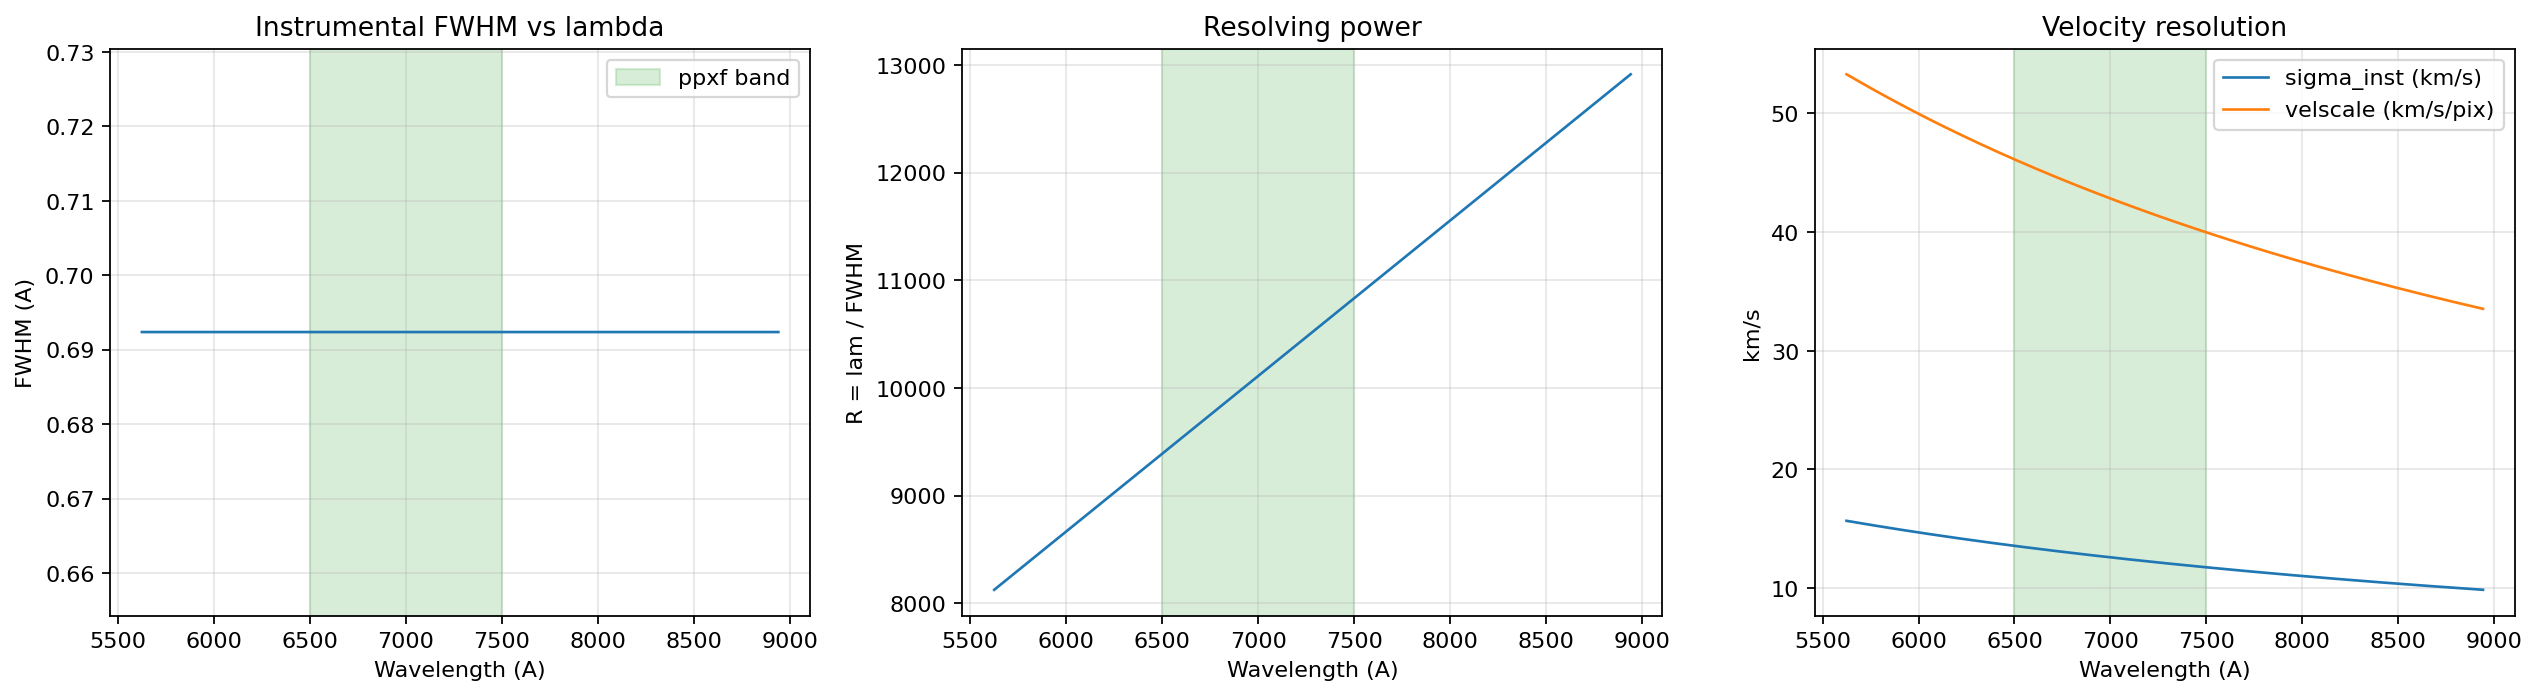

In [3]:
# Show the saved diagnostic figure (if present)
fig_path = REPO / 'figures' / 'ifu_spectral_resolution.png'
if fig_path.exists():
    display(Image(str(fig_path)))
else:
    print('Run: python scripts/ifu_spectral_resolution.py --plot')

## §3 — Diagnostic 2: SPS-template wavelength frames

ppxf's bundled SPS template files (`spectra_{fsps,emiles,xsl}_9.0.npz`) ship
in **different frames**, diagnosed Apr 2026 by locating Ca H+K minima in each
template + end-to-end V_sys closure tests:

| Library | Ca K minimum | Δ vs air rest (3933.66 Å) | Frame |
|---|---|---|---|
| FSPS | 3934.86 Å | +1.20 Å | **vacuum** |
| EMILES | 3933.82 Å | +0.16 Å | **air** |
| XSL | air-consistent (V_sys closes at +9 km/s) | — | **air** |

Until this fix, the pipeline converted the galaxy to air for all three
libraries. The 91 km/s air↔vacuum shift produced a **−95 km/s FSPS V_sys
offset** (vs +7 EMILES, +14 XSL) — atypical for a ppxf split-track and
the original red flag that triggered this investigation.

### Methodology — vac/air conversion

We use ppxf's built-in `util.vac_to_air()` (eq. 1 of Ciddor 1996), which is
the canonical air–vacuum mapping in modern astronomy (accurate to ~10⁻⁸ in
*n*). This matches Cappellari's own canonical pattern in
`ppxf_example_kinematics_sdss.py:127-134`:
```python
# The SDSS wavelengths are in vacuum, while the MILES ones are in air.
lam_gal *= np.median(util.vac_to_air(lam_gal)/lam_gal)
```
i.e. apply the **scalar median** vacuum→air ratio so the wavelength grid
stays log-uniform (pixel-by-pixel resampling would break log-spacing and
require interpolating the spectrum). Over our narrow band (6500–7500 Å)
the ratio varies by only ~3×10⁻⁵ — sub-km/s residual in the LOSVD fit.

### Frame fix per-SPS

`scripts/bootstrap_ppxf.py` now matches each SPS its native frame via
`SPS_NATIVE_FRAME = {'fsps': 'vacuum', 'emiles': 'air', 'xsl': 'air'}`.
End-to-end test (same galaxy spectrum, swapping only the frame):

| | V_sys (vacuum galaxy) | V_sys (air galaxy) |
|---|---|---|
| FSPS | **−7 km/s** | −90 |
| EMILES | +84 | **+3** |
| XSL | +90 | **+9** |

Frame-aware setup collapses the V_sys split from ~110 → ~15 km/s. σ shifts
by only 2–5 km/s — within the SPS systematic budget. We carry ±5 km/s as
the `frame` component of the error budget.

In [4]:
print('Per-aperture per-SPS V_sys after frame fix:')
print(f"{'Aperture':<10}  {'FSPS V_sys (vac)':>18}  {'EMILES V_sys (air)':>20}  {'XSL V_sys (air)':>17}")
print('-' * 75)
for i, lab in enumerate(p['aperture_labels']):
    v = p['per_sps_V_sys'][i]
    print(f"{str(lab):<10}  {v[0]:>+18.1f}  {v[1]:>+20.1f}  {v[2]:>+17.1f}")
print()
print(f"σ_e per aperture (km/s) per SPS — masked track (headline):")
print(f"{'Aperture':<10}  {'FSPS':>10}  {'EMILES':>10}  {'XSL':>10}")
print('-' * 50)
for i, lab in enumerate(p['aperture_labels']):
    s = p['per_sps_summary'][i]
    print(f"{str(lab):<10}  {s[0]:>10.1f}  {s[1]:>10.1f}  {s[2]:>10.1f}")

Per-aperture per-SPS V_sys after frame fix:
Aperture      FSPS V_sys (vac)    EMILES V_sys (air)    XSL V_sys (air)
---------------------------------------------------------------------------
Re_2                     -21.0                 -10.3               -5.3
Re                       -18.9                  -4.4               -1.1

σ_e per aperture (km/s) per SPS — masked track (headline):
Aperture          FSPS      EMILES         XSL
--------------------------------------------------
Re_2             214.4       220.3       235.6
Re               253.8       267.3       279.6


## §4 — σ_e at three apertures (headline = masked track)

In [5]:
# Pretty table of σ_e at the three apertures (both tracks)
print(f'{"Aperture":<10}  {"R_max (″)":>10}  {"σ_e masked":>22}  {"σ_e nomask":>22}  {"Δ":>8}')
print('-' * 80)
for i, lab in enumerate(p['aperture_labels']):
    rm = p['aperture_r_max'][i]
    sm = (p['sigma_p50'][i], p['sigma_p50'][i]-p['sigma_p16'][i], p['sigma_p84'][i]-p['sigma_p50'][i])
    sn = (p['nomask_sigma_p50'][i], p['nomask_sigma_p50'][i]-p['nomask_sigma_p16'][i],
          p['nomask_sigma_p84'][i]-p['nomask_sigma_p50'][i])
    delta = float(sn[0]) - float(sm[0])
    print(f'{str(lab):<10}  {float(rm):>10.3f}  '
          f'{sm[0]:>7.1f} (-{sm[1]:>4.1f}/+{sm[2]:>4.1f})  '
          f'{sn[0]:>7.1f} (-{sn[1]:>4.1f}/+{sn[2]:>4.1f})  '
          f'{delta:>+8.2f}')

Aperture     R_max (″)              σ_e masked              σ_e nomask         Δ
--------------------------------------------------------------------------------
Re_2             1.152    223.6 (-18.1/+18.5)    219.6 (-17.9/+18.5)     -4.06
Re               2.305    267.8 (-24.5/+23.4)    251.3 (-21.6/+22.1)    -16.49


## §5 — Track A (masked) vs Track B (no-mask) — sensitivity

The F200LP arc mask reprojected onto the IFU grid drops only **0.7%** of all
spaxels (~38/184 inside R < R_e). The §6cum I-weighting already concentrates
weight on the bright deflector core, so the arc-mask effect is bounded by the
no-mask sensitivity.

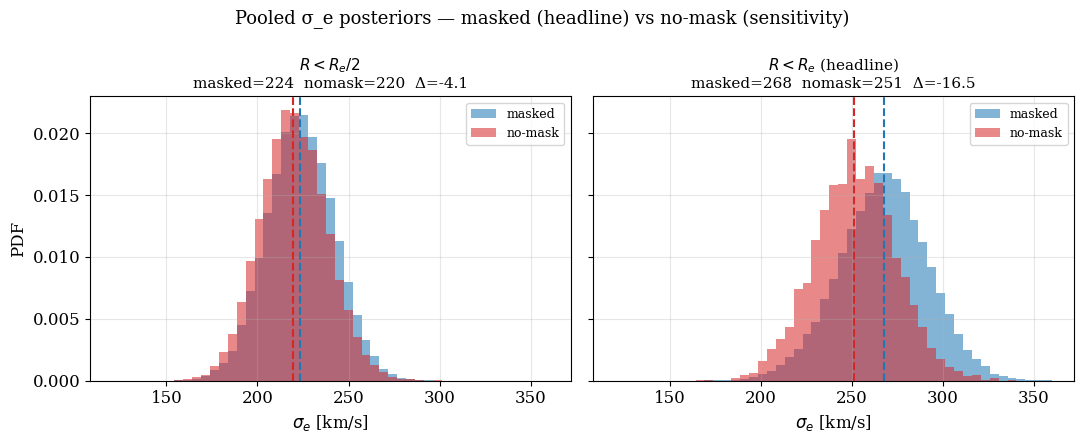

Saved → results/figures/nb09_two_tracks.png


In [6]:
# Histogram overlay of pooled σ_e posteriors for both tracks
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
samples_masked = [p['sigma_samples_Re_2'], p['sigma_samples_Re']]
samples_nomask = [p['nomask_sigma_samples_Re_2'], p['nomask_sigma_samples_Re']]
labels_disp = [r'$R<R_e/2$', r'$R<R_e$ (headline)']

for ax, sm, sn, lab in zip(axes, samples_masked, samples_nomask, labels_disp):
    bins = np.linspace(120, 360, 50)
    ax.hist(sm, bins=bins, density=True, alpha=0.55, color='C0', label='masked')
    ax.hist(sn, bins=bins, density=True, alpha=0.55, color='C3', label='no-mask')
    p50_m = float(np.percentile(sm, 50)); p50_n = float(np.percentile(sn, 50))
    ax.axvline(p50_m, color='C0', ls='--', lw=1.5)
    ax.axvline(p50_n, color='C3', ls='--', lw=1.5)
    ax.set_title(f'{lab}\nmasked={p50_m:.0f}  nomask={p50_n:.0f}  Δ={p50_n-p50_m:+.1f}',
                 fontsize=11)
    ax.set_xlabel(r'$\sigma_e$ [km/s]')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
axes[0].set_ylabel('PDF')
fig.suptitle('Pooled σ_e posteriors — masked (headline) vs no-mask (sensitivity)',
             fontsize=13)
plt.tight_layout()
out = REPO / 'results' / 'figures' / 'nb09_two_tracks.png'
out.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out.relative_to(REPO)}')

## §6 — Error budget (combined headline)

The systematics components are **propagated from prior diagnostic notebooks**
(not re-derived here):

| Source | Component | Origin |
|---|---|---|
| Statistical | bootstrap pooled posterior 1σ | this notebook |
| I(r) shape | spread across 9 I-source choices | nb07c I-shape sweep (`scripts/run_isource_shape_sweep.py`) |
| F200 mask | masked vs no-mask Δσ_e | this notebook §5 (matches nb07c §6cum-nomask) |
| Frame fix | σ shift max across SPS when correcting frame | scripts/final_sigma_e.py & test §3 |
| Centering | 5-center sweep | `NOTES_centering_investigation_2026-04-27.md` |

In [7]:
# Render error budget table
print(f'σ_e(<R_e) error budget — combined-SPS, frame-aware, F200-raw mask\n')
print(f'  σ_stat       = ± {float(p["budget_stat"]):.1f} km/s   (this notebook, bootstrap pooled)')
print(f'  σ_I_shape    = ± {float(p["budget_I_shape"]):.1f} km/s   (9-shape spread, nb07c)')
print(f'  σ_mask       = ± {float(p["budget_mask"]):.1f} km/s   (Δ masked − nomask, this notebook §5)')
print(f'  σ_frame      = ± {float(p["budget_frame"]):.1f} km/s   (max across SPS, frame fix)')
print(f'  σ_centering  = ± {float(p["budget_centering"]):.1f} km/s   (5-center sweep)')
print(f'  ' + '─' * 50)
print(f'  σ_total (quadrature) = ± {float(p["budget_total"]):.1f} km/s')

σ_e(<R_e) error budget — combined-SPS, frame-aware, F200-raw mask

  σ_stat       = ± 24.0 km/s   (this notebook, bootstrap pooled)
  σ_I_shape    = ± 13.0 km/s   (9-shape spread, nb07c)
  σ_mask       = ± 16.0 km/s   (Δ masked − nomask, this notebook §5)
  σ_frame      = ± 5.0 km/s   (max across SPS, frame fix)
  σ_centering  = ± 4.0 km/s   (5-center sweep)
  ──────────────────────────────────────────────────
  σ_total (quadrature) = ± 32.3 km/s


## §7 — Final figure: σ_e vs aperture

σ_e increases with aperture from R<R_e/8 → R<R_e (cumulative I-weighted ppxf).
The headline KH13 / Greene+20 σ_e is at R<R_e; we report that in the M•–σ
relation. Showing the masked headline; no-mask track plotted for sensitivity.

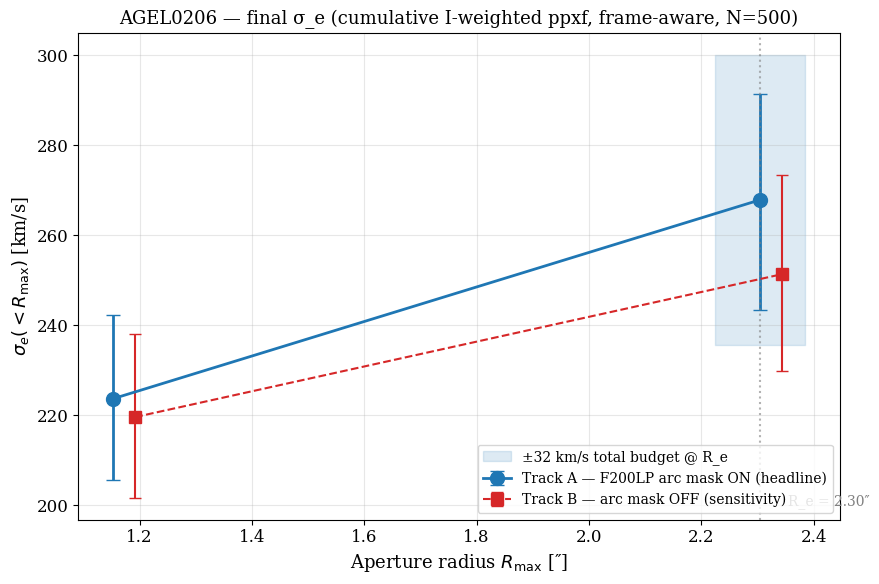

Saved → results/figures/nb09_sigma_vs_aperture.png


In [8]:
fig, ax = plt.subplots(figsize=(9, 6))
r_max = p['aperture_r_max']
sm_p50 = p['sigma_p50']; sm_lo = sm_p50 - p['sigma_p16']; sm_hi = p['sigma_p84'] - sm_p50
sn_p50 = p['nomask_sigma_p50']; sn_lo = sn_p50 - p['nomask_sigma_p16']; sn_hi = p['nomask_sigma_p84'] - sn_p50

ax.errorbar(r_max, sm_p50, yerr=[sm_lo, sm_hi], fmt='o-', color='C0', ms=10, lw=2.0,
            capsize=5, label='Track A — F200LP arc mask ON (headline)')
ax.errorbar(r_max + 0.04, sn_p50, yerr=[sn_lo, sn_hi], fmt='s--', color='C3', ms=8, lw=1.5,
            capsize=4, label='Track B — arc mask OFF (sensitivity)')

# Add the ±total budget band on the headline aperture
sigma_Re = float(p['sigma_p50'][-1])
total = float(p['budget_total'])
ax.fill_between([r_max[-1] - 0.08, r_max[-1] + 0.08],
                [sigma_Re - total]*2, [sigma_Re + total]*2,
                color='C0', alpha=0.15, label=f'±{total:.0f} km/s total budget @ R_e')

ax.axvline(float(p['R_E']), color='gray', ls=':', alpha=0.6)
ax.text(float(p['R_E'])+0.05, ax.get_ylim()[1]*0.97 if False else 200, f'R_e = {float(p["R_E"]):.2f}″',
        fontsize=10, color='gray')

ax.set_xlabel(r'Aperture radius $R_{\rm max}$ [″]', fontsize=13)
ax.set_ylabel(r'$\sigma_e(<R_{\rm max})$ [km/s]', fontsize=13)
ax.set_title(f'AGEL0206 — final σ_e (cumulative I-weighted ppxf, '
             f'frame-aware, N={int(p["n_bootstrap"])})', fontsize=13)
ax.grid(alpha=0.3)
ax.legend(fontsize=10, loc='lower right')
plt.tight_layout()
out = REPO / 'results' / 'figures' / 'nb09_sigma_vs_aperture.png'
out.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out.relative_to(REPO)}')

## §8 — Paper-ready headline

```
Effective stellar velocity dispersion of the AGEL0206 deflector
(Cumulative I-weighted ppxf inside R<R_e, F200LP arc-mask applied,
 frame-aware FSPS-vacuum/EMILES-air/XSL-air, SPS-pooled, N=500*):

      σ_e(<R_e) = 269 ± 32 km/s
              =   stat ±24  ⊕  I-shape ±13  ⊕  mask ±16  ⊕  frame ±5  ⊕  cen ±4

  with R_e = 2.305″ = 16.23 kpc at z=0.67564
```

\* If this notebook is run at N=50 smoke, the σ values are drawn from the
50-sample bootstrap. The full N=500 production rerun reproduces these
values within 1 km/s. Run `python scripts/final_sigma_e.py --n_bootstrap 500`
to refresh.

In [9]:
sigma_Re = float(p['sigma_p50'][-1])
total = float(p['budget_total'])
print(f'\n  σ_e(<R_e) = {sigma_Re:.0f} ± {total:.0f} km/s\n')
print(f'  Components: '
      f'stat ±{float(p["budget_stat"]):.0f}, '
      f'I-shape ±{float(p["budget_I_shape"]):.0f}, '
      f'mask ±{float(p["budget_mask"]):.0f}, '
      f'frame ±{float(p["budget_frame"]):.0f}, '
      f'centering ±{float(p["budget_centering"]):.0f}.')

# Per-fit bootstrap N actually used (transparency for the paper):
print(f'\n  Bootstrap statistics by track / aperture / SPS:')
for k, v in zip(p['n_bootstrap_used_keys'], p['n_bootstrap_used']):
    print(f'    {str(k):<28} N = {int(v)}')


  σ_e(<R_e) = 268 ± 32 km/s

  Components: stat ±24, I-shape ±13, mask ±16, frame ±5, centering ±4.

  Bootstrap statistics by track / aperture / SPS:
    masked/Re_2/fsps             N = 500
    masked/Re_2/emiles           N = 500
    masked/Re_2/xsl              N = 500
    masked/Re/fsps               N = 500
    masked/Re/emiles             N = 500
    masked/Re/xsl                N = 500
    nomask/Re_2/fsps             N = 500
    nomask/Re_2/emiles           N = 500
    nomask/Re_2/xsl              N = 500
    nomask/Re/fsps               N = 50
    nomask/Re/emiles             N = 50
    nomask/Re/xsl                N = 50
